In [1]:
#Imports and Loading Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # For saving the Random Forest model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load the split datasets
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Separate Features (X) and Target (y)
X_train = train_data.drop('Labelling', axis=1)
y_train = train_data['Labelling']

X_test = test_data.drop('Labelling', axis=1)
y_test = test_data['Labelling']

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

# Dictionary to store performance for both models
model_performance = {}

Training Features Shape: (23996, 26)
Testing Features Shape: (6000, 26)


In [2]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier

print("--- Training Random Forest ---")
# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make Predictions
rf_preds = rf_model.predict(X_test)

# Calculate Metrics
rf_acc = accuracy_score(y_test, rf_preds)
rf_prec = precision_score(y_test, rf_preds)
rf_rec = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

# Store Performance
model_performance['Random Forest'] = {'Accuracy': rf_acc, 'Precision': rf_prec, 'Recall': rf_rec, 'F1-Score': rf_f1}

# Save the Model
joblib.dump(rf_model, 'random_forest_model.pkl')

print("Random Forest Training Complete!")
print(f"Accuracy: {rf_acc:.4f} | F1-Score: {rf_f1:.4f}")
print("Model saved as 'random_forest_model.pkl'")

--- Training Random Forest ---
Random Forest Training Complete!
Accuracy: 0.9442 | F1-Score: 0.9568
Model saved as 'random_forest_model.pkl'


In [3]:
#Feature Scaling for Neural Network
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# We fit the scaler ONLY on the training data to prevent data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler so you can use it later for new patient predictions!
joblib.dump(scaler, 'minmax_scaler.pkl')

print("Data successfully scaled for the Neural Network!")

Data successfully scaled for the Neural Network!


In [4]:
# BLOCK 4: Artificial Neural Network (ANN) Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("--- Training Artificial Neural Network ---")
# 1. Build the Architecture
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3), # Drops 30% of neurons randomly to prevent overfitting
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Sigmoid outputs a probability between 0 and 1
])

# 2. Compile the Model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Define Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 4. Train the Model (Using 20% of training data for validation)
history = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 5. Make Predictions (Convert probabilities to 0 or 1)
ann_probs = ann_model.predict(X_test_scaled)
ann_preds = (ann_probs > 0.5).astype(int).flatten()

# 6. Calculate Metrics
ann_acc = accuracy_score(y_test, ann_preds)
ann_prec = precision_score(y_test, ann_preds)
ann_rec = recall_score(y_test, ann_preds)
ann_f1 = f1_score(y_test, ann_preds)

# 7. Store Performance and Save Model
model_performance['Standard ANN'] = {'Accuracy': ann_acc, 'Precision': ann_prec, 'Recall': ann_rec, 'F1-Score': ann_f1}
ann_model.save('ann_model.h5')

print("\nANN Training Complete!")
print(f"Accuracy: {ann_acc:.4f} | F1-Score: {ann_f1:.4f}")
print("Model saved as 'ann_model.h5'")

--- Training Artificial Neural Network ---
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7738 - loss: 0.4637 - val_accuracy: 0.8985 - val_loss: 0.2674
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8823 - loss: 0.2983 - val_accuracy: 0.9121 - val_loss: 0.2383
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8996 - loss: 0.2591 - val_accuracy: 0.9194 - val_loss: 0.2189
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9107 - loss: 0.2306 - val_accuracy: 0.9281 - val_loss: 0.2114
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9200 - loss: 0.2150 - val_accuracy: 0.9348 - val_loss: 0.1967
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9272 - loss: 0.2091 - val_accuracy: 0.9348 - val_loss: 0.1989
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9328 - loss: 0.1991 - val_accuracy: 0.9390 - val_loss: 0.1917
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9346 - loss: 0.1915 - val_accuracy: 0.9348


ANN Training Complete!
Accuracy: 0.9420 | F1-Score: 0.9550
Model saved as 'ann_model.h5'


=== FINAL BASELINE MODEL PERFORMANCE ===


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.944167,0.953201,0.960363,0.956769
Standard ANN,0.942000,0.953981,0.955959,0.954969



Performance metrics saved to 'baseline_models_performance.csv'


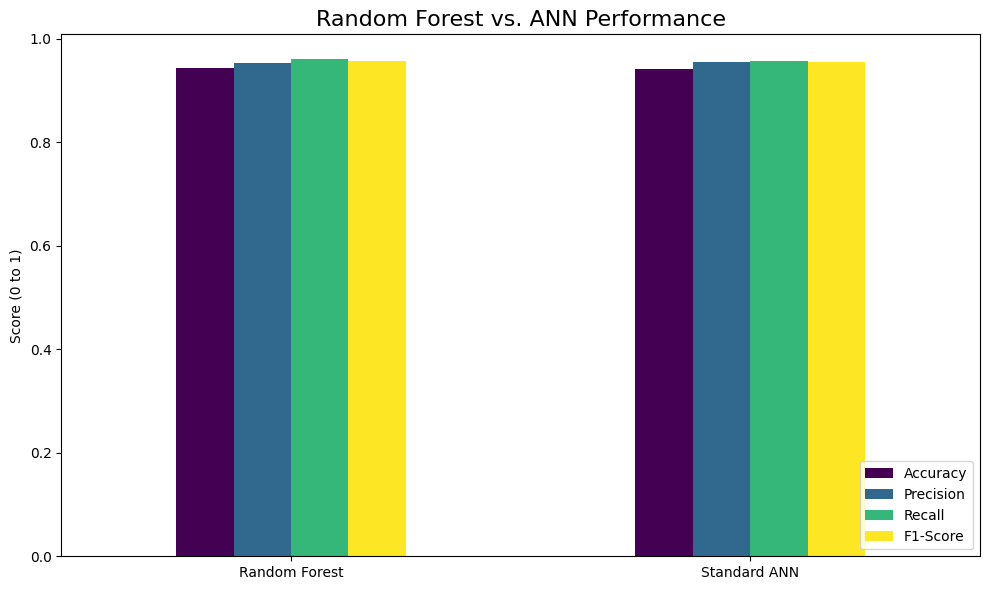

In [5]:
# Model Comparison & Saving Metrics
# Convert the dictionary to a DataFrame for easy viewing
performance_df = pd.DataFrame(model_performance).T

# Display the final results
print("=== FINAL BASELINE MODEL PERFORMANCE ===")
display(performance_df)

# Save the metrics to a CSV for your records
performance_df.to_csv('baseline_models_performance.csv')
print("\nPerformance metrics saved to 'baseline_models_performance.csv'")

# Optional: Plot the comparison
performance_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Random Forest vs. ANN Performance', fontsize=16)
plt.ylabel('Score (0 to 1)')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()